In [1]:
import netCDF4

### PIXCVec

In [14]:
def print_groups(group, indent=""):
    """Recursively walks and prints all groups in a NetCDF dataset."""
    for name, subgroup in group.groups.items():
        print(f"{indent}📁 Group: {name}")
        # Recursively search for deeper nested groups
        if subgroup.groups:
            print_groups(subgroup, indent + "  ")

# Open your output file
dataset = netCDF4.Dataset('/nas/cee-water/cjgleason/fiona/RiverObs/src/bin/SWOT_L2_HR_PIXCVec_013_341_229R_20240408T184449_20240408T184500_PIC0_01.nc', 'r')

print("Root File Structure:")
if not dataset.groups:
    print("No groups found. All variables are stored in the root directory.")
else:
    print_groups(dataset)

dataset.close()

Root File Structure:
No groups found. All variables are stored in the root directory.


In [16]:
# Open the flat NetCDF file
ds = netCDF4.Dataset('/nas/cee-water/cjgleason/fiona/RiverObs/src/bin/SWOT_L2_HR_PIXCVec_013_341_229R_20240408T184449_20240408T184500_PIC0_01.nc', 'r')

print(f"{'Variable Name':<30} | {'Dimensions':<15} | {'Long Name / Description'}")
print("-" * 80)

# Loop through and print metadata for each flat variable
for name, var in sorted(ds.variables.items()):
    dims = str(var.dimensions)
    long_name = var.getncattr('long_name') if 'long_name' in var.ncattrs() else 'No description'
    print(f"{name:<30} | {dims:<15} | {long_name}")

ds.close()

Variable Name                  | Dimensions      | Long Name / Description
--------------------------------------------------------------------------------
along_reach                    | ('points',)     | along reach distance
area_flg                       | ('points',)     | area flag
azimuth_index                  | ('points',)     | rare interferogram azimuth index
classification_qual            | ('points',)     | classification_qual
cross_reach                    | ('points',)     | across reach distance
distance_to_node               | ('points',)     | distance to node
geolocation_qual               | ('points',)     | geolocation_qual
h_flg                          | ('points',)     | height flag
height_vectorproc              | ('points',)     | height above reference ellipsoid
ice_clim_f                     | ('points',)     | climatological ice cover flag
ice_dyn_f                      | ('points',)     | dynamical ice cover flag
lake_flag                      | ('points',

### RiverTile

In [13]:
def print_groups(group, indent=""):
    """Recursively walks and prints all groups in a NetCDF dataset."""
    for name, subgroup in group.groups.items():
        print(f"{indent}📁 Group: {name}")
        # Recursively search for deeper nested groups
        if subgroup.groups:
            print_groups(subgroup, indent + "  ")

# Open your output file
dataset = netCDF4.Dataset('/nas/cee-water/cjgleason/fiona/RiverObs/src/bin/SWOT_L2_HR_RiverTile_013_341_229R_20240408T184449_20240408T184500_PIC0_01.nc', 'r')

print("Root File Structure:")
if not dataset.groups:
    print("No groups found. All variables are stored in the root directory.")
else:
    print_groups(dataset)

dataset.close()

Root File Structure:
📁 Group: nodes
📁 Group: reaches


### RiverSP

In [32]:
# river_sp_path = '/nas/cee-water/cjgleason/fiona/RiverObs/src/bin/SWOT_L2_HR_RiverSP_013_341_229R_20240408T184449_20240408T184500_PIC0_01.nc'
river_sp_path = '/nas/cee-water/cjgleason/fiona/RiverObs/src/bin/SWOT_L2_HR_RiverSP_046_345_241R_20260226T110012_20260226T110023_PID0_01.nc'

In [33]:
def print_groups(group, indent=""):
    """Recursively walks and prints all groups in a NetCDF dataset."""
    for name, subgroup in group.groups.items():
        print(f"{indent}📁 Group: {name}")
        # Recursively search for deeper nested groups
        if subgroup.groups:
            print_groups(subgroup, indent + "  ")

# Open your output file
dataset = netCDF4.Dataset(river_sp_path, 'r')

print("Root File Structure:")
if not dataset.groups:
    print("No groups found. All variables are stored in the root directory.")
else:
    print_groups(dataset)

dataset.close()

Root File Structure:
📁 Group: nodes
📁 Group: reaches


In [34]:
# Open the flat NetCDF file
ds = netCDF4.Dataset(river_sp_path, 'r')

reach_group = ds.groups['reaches']


print(f"--- Metadata for Group: reaches ---")
print(f"{'Variable Name':<30} | {'Dimensions':<15} | {'Long Name / Description'}")
print("-" * 80)

# Loop through and print metadata for each flat variable
for name, var in sorted(reach_group.variables.items()):
    dims = str(var.dimensions)
    long_name = var.getncattr('long_name') if 'long_name' in var.ncattrs() else 'No description'
    print(f"{name:<30} | {dims:<15} | {long_name}")

ds.close()

--- Metadata for Group: reaches ---
Variable Name                  | Dimensions      | Long Name / Description
--------------------------------------------------------------------------------
area_det_u                     | ('reaches',)    | uncertainty in the surface area of detected water
area_detct                     | ('reaches',)    | surface area of detected water pixels
area_tot_u                     | ('reaches',)    | uncertainty in the total water surface area
area_total                     | ('reaches',)    | total water surface area including dark water
area_wse                       | ('reaches',)    | area used to compute water surface elevation
centerline_lat                 | ('reaches', 'centerlines') | Latitude of the centerline of the reach from prior database
centerline_lon                 | ('reaches', 'centerlines') | Longitude of the centerline of the reach from prior database
d_x_area                       | ('reaches',)    | change in cross-sectional area
d_x

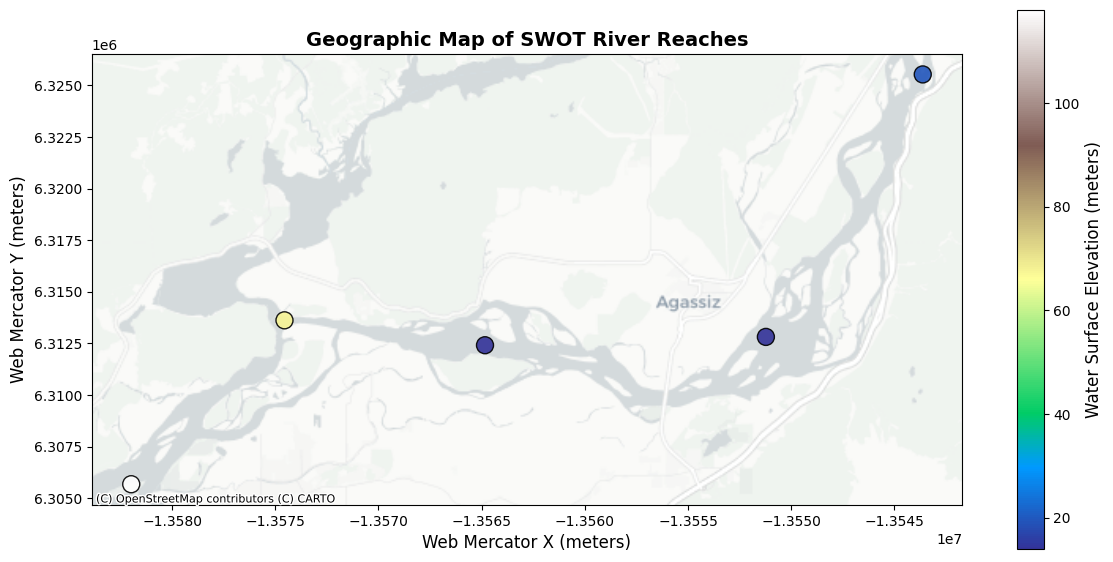

In [41]:
import netCDF4
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# 1. Define your path and open the file
ds = netCDF4.Dataset(river_sp_path, 'r')
reach_group = ds.groups['reaches']

# 2. Extract coordinates and elevation metrics using the Prior Database keys
lons = reach_group.variables['p_lon'][:].filled(float('nan'))
lats = reach_group.variables['p_lat'][:].filled(float('nan'))
wse = reach_group.variables['wse'][:].filled(float('nan'))
reach_ids = reach_group.variables['reach_id'][:]

ds.close()

# 3. Create a structured Pandas DataFrame and drop missing data
df = pd.DataFrame({
    'reach_id': reach_ids,
    'longitude': lons,
    'latitude': lats,
    'wse': wse
}).dropna(subset=['wse', 'longitude', 'latitude'])

# 4. Convert the DataFrame into a Geospatial GeoDataFrame (WGS84)
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Plot the river reaches as coordinates colored by water height
sc = gdf.plot(column='wse', cmap='terrain', ax=ax, legend=False,
              markersize=150, edgecolor='black', alpha=0.9, zorder=2)

try:
    import contextily as ctx
    use_basemap = True
    # Re-project to Web Mercator (EPSG:3857) to cleanly match background tiles
    gdf_plot = gdf.to_crs(epsg=3857)
except ImportError:
    use_basemap = False
    gdf_plot = gdf

# 6. Initialize exactly ONE canvas
fig, ax = plt.subplots(figsize=(12, 8))

# 7. Plot the data onto the single axis
sc = gdf_plot.plot(column='wse', cmap='terrain', ax=ax, legend=False,
                   markersize=150, edgecolor='black', alpha=0.9, zorder=2)

# 8. Apply background styling based on contextily availability
if use_basemap:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    plt.xlabel('Web Mercator X (meters)', fontsize=12)
    plt.ylabel('Web Mercator Y (meters)', fontsize=12)
else:
    # Fallback styling if contextily isn't installed
    ax.set_facecolor('#f0f0f0')
    ax.grid(True, color='white', linestyle='-', linewidth=1.5)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)

# Add titles and final formatting
plt.title('Geographic Map of SWOT River Reaches', fontsize=14, fontweight='bold')

# Add colorbar for elevation height scaling
sm = plt.cm.ScalarMappable(cmap='terrain', norm=plt.Normalize(vmin=df['wse'].min(), vmax=df['wse'].max()))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7)
cbar.set_label('Water Surface Elevation (meters)', fontsize=12)

plt.tight_layout()
plt.show()